In [49]:
import os
from langchain.tools import tool
from langchain.chat_models import init_chat_model
from langchain_google_genai import ChatGoogleGenerativeAI
import requests
from dotenv import load_dotenv
load_dotenv()

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
OPEN_WEATHER_API_KEY = os.getenv("OPEN_WEATHER_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY

model = ChatGoogleGenerativeAI(
    model= "gemini-3-flash-preview",
    temperature=1.0,
    max_retries=2,
    google_api_key=GEMINI_API_KEY
)


# Define tools
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b

@tool
def get_weather(city: str):
    """Get the current weather for a city.

    Args:
        city: Name of the city
    """
    if not OPEN_WEATHER_API_KEY:
        return "Error: OPEN_WEATHER_API_KEY is not set."

    url = "https://api.openweathermap.org/data/2.5/weather"
    params = {
        "q": city,
        "appid": OPEN_WEATHER_API_KEY,
        "units": "metric",
    }

    try:
        response = requests.get(url, params=params, timeout=10)
        data = response.json()

        if response.status_code == 200:
            temp = data["main"]["temp"]
            description = data["weather"][0]["description"]
            return f"The weather in {city} is {description} with temperature {temp}°C."
        else:
            # This is the key fix — show the actual API error
            return f"API error {response.status_code}: {data.get('message', 'Unknown error')}"

    except requests.RequestException as e:
        return f"Network error: {e}"
    

@tool
def internet_search(topic: str):
    """use this function to search abiut any topic on internet
    Args:
       topic: str
    """
    # To install: pip install tavily-python
    from tavily import TavilyClient
    client = TavilyClient("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")
    response = client.search(
        query=topic,
        search_depth="advanced"
    )
    print(response)

# Augment the LLM with tools
tools = [add, multiply, divide, get_weather, internet_search]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

In [50]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator


class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

In [51]:
from langchain.messages import SystemMessage


def llm_call(state: dict):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            model_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs. And can tell about the weather of Any City use Tool to get the weather. Can Search on INternet about any Topic "
                    )
                ]
                + state["messages"]
            )
        ],
        "llm_calls": state.get('llm_calls', 0) + 1
    }

In [52]:
from langchain.messages import ToolMessage


def tool_node(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}

In [47]:
from typing import Literal
from langgraph.graph import StateGraph, START, END


def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return END

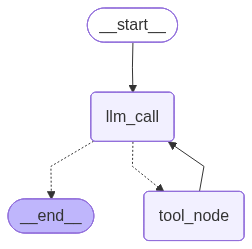

{'query': 'Agentic AI in 2026', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://medium.com/@anicomanesh/from-generative-to-agentic-ai-a-roadmap-in-2026-8e553b43aeda', 'title': 'From Generative to Agentic AI: A Roadmap in 2026', 'content': 'The move to agentic AI offers enormous potential to automate complex tasks, but safe, reliable deployment depends on governance, not on any magical increase in “machine intelligence.” Modern LLMs are powerful, but they still make mistakes — and when an agent’s actions have real-world consequences, those mistakes must be contained. [...] “Unlike traditional automation that follows predetermined rules, agentic AI demonstrates autonomous decision-making, continuous learning, and adaptive behavior that fundamentally transforms industrial operations”. Surveys and forecasts bear this out: Gartner named agentic AI a top trend for 2026, and a Deloitte study predicts that half of enterprises using GenAI will deploy auto

In [53]:
# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()

# Show the agent
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# Invoke
from langchain.messages import HumanMessage
messages = [HumanMessage(content="Search about the Agentic ai in 2026")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()